In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.DataFrame({
    "age": [
        18, 19, 20, 21, 22, 23, 19, 20, 21, 22,
        24, 25, 20, 21, 22, 23, 19, 20, 250, 22
    ],

    "hours": [
        1, 2, 3, 5, 6, 7, 2, 4, 5, 6,
        8, 9, 3, np.nan, 6, 7, 2, 4, 8, 5
    ],

    "sleep": [
        8, 8, 7, 7, 6, 6, 8, 7, 7, 6,
        6, 5, 7, 7, 6, 6, 8, 7, 5, 7
    ],

    "city": [
        "Moscow", "Moscow", "Berlin", "Moscow", "Berlin",
        "Paris", "Moscow", "Berlin", "Moscow", "Paris",
        "Berlin", "Paris", "Moscow", "Berlin", "Paris",
        "Moscow", "Berlin", "Paris", "Moscow", "Berlin"
    ],

    "passed": [
        0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
        1, 1, 0, 1, 1, 1, 0, 0, 1, 1
    ]
})

In [37]:
df.shape

(20, 5)

In [38]:
df.dtypes

age         int64
hours     float64
sleep       int64
city          str
passed      int64
dtype: object

In [39]:
df.head()

,age,hours,sleep,city,passed
0,18,1.0,8,Moscow,0
1,19,2.0,8,Moscow,0
2,20,3.0,7,Berlin,0
3,21,5.0,7,Moscow,1
4,22,6.0,6,Berlin,1


In [40]:
df.isna().sum()

age       0
hours     1
sleep     0
city      0
passed    0
dtype: int64

In [41]:
df.duplicated().sum()

3

{'whiskers': [<matplotlib.lines.Line2D at 0x16ad21050>,
 'caps': [<matplotlib.lines.Line2D at 0x16ad20850>,
 'boxes': [<matplotlib.lines.Line2D at 0x16ad996d0>],
 'medians': [<matplotlib.lines.Line2D at 0x16ad20d90>],
 'fliers': [<matplotlib.lines.Line2D at 0x16ad23250>],
 'means': []}

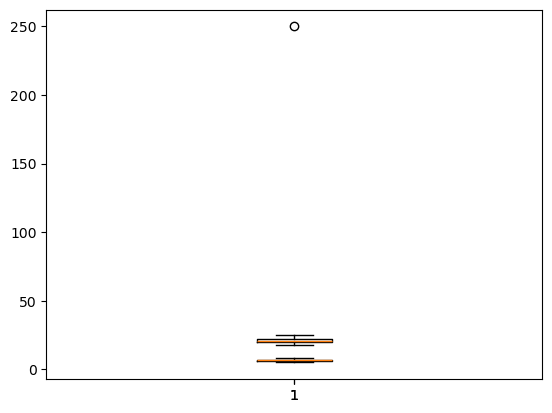

In [42]:
plt.boxplot(df["age"])
plt.boxplot(df["hours"])
plt.boxplot(df["sleep"])


In [43]:
df.describe()

,age,hours,sleep,passed
count,20.000000,19.000000,20.000000,20.000000
mean,32.550000,4.894737,6.700000,0.600000
std,51.214179,2.330826,0.923381,0.502625
min,18.000000,1.000000,5.000000,0.000000
25%,20.000000,3.000000,6.000000,0.000000
50%,21.000000,5.000000,7.000000,1.000000
75%,22.250000,6.500000,7.000000,1.000000
max,250.000000,9.000000,8.000000,1.000000


In [44]:
### --- Age
age_q1 = df["age"].quantile(0.25)
age_q3 = df["age"].quantile(0.75)

IQR_age = age_q3 - age_q1

upper_age = age_q3 + 1.5 * IQR_age
lower_age = age_q1 - 1.5 * IQR_age

mask_age = (df["age"] > upper_age) | (df["age"] < lower_age)

### --- Hours
hours_q1 = df["hours"].quantile(0.25)
hours_q3 = df["hours"].quantile(0.75)

IQR_hours = hours_q3 - hours_q1

upper_hours = hours_q3 + 1.5 * IQR_hours
lower_hours = hours_q1 - 1.5 * IQR_hours

mask_hours = (df["hours"] > upper_hours) | (df["hours"] < lower_hours)

### --- Sleep
sleep_q1 = df["sleep"].quantile(0.25)
sleep_q3 = df["sleep"].quantile(0.75)

IQR_sleep = sleep_q3 - sleep_q1

upper_sleep = sleep_q3 + 1.5 * IQR_sleep
lower_sleep = sleep_q1 - 1.5 * IQR_sleep

mask_sleep = (df["sleep"] > upper_sleep) | (df["sleep"] < lower_sleep)

print(df.loc[mask_age, "age"])
print(df.loc[mask_hours, "hours"])
print(df.loc[mask_sleep, "sleep"])


18    250
Name: age, dtype: int64
Series([], Name: hours, dtype: float64)
Series([], Name: sleep, dtype: int64)


In [45]:
df["city"].value_counts()


city
Moscow    8
Berlin    7
Paris     5
Name: count, dtype: int64

In [46]:
df["passed"].value_counts(normalize=True)

passed
1    0.6
0    0.4
Name: proportion, dtype: float64

In [47]:
df.corr(numeric_only=True)

,age,hours,sleep,passed
age,1.000000,0.355334,-0.462653,0.215503
hours,0.355334,1.000000,-0.948249,0.853208
sleep,-0.462653,-0.948249,1.000000,-0.725775
passed,0.215503,0.853208,-0.725775,1.000000


In [48]:
print(df.groupby("passed")[["age","hours", "sleep"]].mean())



              age     hours     sleep
passed                               
0       19.375000  2.625000  7.500000
1       41.333333  6.545455  6.166667


Тип задачи: Классификация

Размер данных: 20 строк и 4 признака, последний 5ый столбец показывает класс

Пропусков всего 1

Нужно убрать несколько дубликатов и заполнить пропуски

Таргет это просто сдал или не сдал

Корреляция указана и видна, думаю нет особого смысла в 5ом задании

СИльнее всего разделяет группы hours

Имеються пропуски и дубликаты, но это поправимо

Дисбалас есть но он не критичен

